# Loan Default Prediction - Exploratory Data Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 2. Load the Dataset

In [3]:
df = pd.read_csv('/content/Givaji Pravalika - Dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows   : {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset Shape: (121856, 40)
Total Rows   : 121856
Total Columns: 40


In [8]:
# Preview first few rows
df.head()

,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


In [9]:
# Basic info about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          121856 non-null  int64  
 1   Client_Income               118249 non-null  object 
 2   Car_Owned                   118275 non-null  float64
 3   Bike_Owned                  118232 non-null  float64
 4   Active_Loan                 118221 non-null  float64
 5   House_Own                   118195 non-null  float64
 6   Child_Count                 118218 non-null  float64
 7   Credit_Amount               118224 non-null  object 
 8   Loan_Annuity                117044 non-null  object 
 9   Accompany_Client            120110 non-null  object 
 10  Client_Income_Type          118155 non-null  object 
 11  Client_Education            118211 non-null  object 
 12  Client_Marital_Status       118383 non-null  object 
 13  Client_Gender 

## 3. Fix Data Types

Some numeric columns got loaded as text (object) because of mixed values in the CSV. We need to fix those first.

In [10]:
# These columns should be numeric but are stored as text
numeric_cols_to_fix = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity',
    'Population_Region_Relative', 'Age_Days', 'Employed_Days',
    'Registration_Days', 'ID_Days', 'Score_Source_3'
]

for col in numeric_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types fixed!")
print(df[numeric_cols_to_fix].dtypes)

Data types fixed!
Client_Income                 float64
Credit_Amount                 float64
Loan_Annuity                  float64
Population_Region_Relative    float64
Age_Days                      float64
Employed_Days                 float64
Registration_Days             float64
ID_Days                       float64
Score_Source_3                float64
dtype: object


## 4. Check for Missing Values

In [11]:
# Count missing values per column
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                            Missing Count  Missing %
Own_House_Age                       80095      65.73
Score_Source_1                      68835      56.49
Social_Circle_Default               61928      50.82
Client_Occupation                   41435      34.00
Score_Source_3                      26922      22.09
Credit_Bureau                       18540      15.21
ID_Days                              5985       4.91
Score_Source_2                       5686       4.67
Population_Region_Relative           4868       3.99
Loan_Annuity                         4826       3.96
Client_Income_Type                   3701       3.04
Client_Housing_Type                  3687       3.03
Application_Process_Hour             3663       3.01
Employed_Days                        3666       3.01
Phone_Change                         3664       3.01
House_Own                            3661       3.00
Loan_Contract_Type                   3651       3.00
Client_Education                     3645     

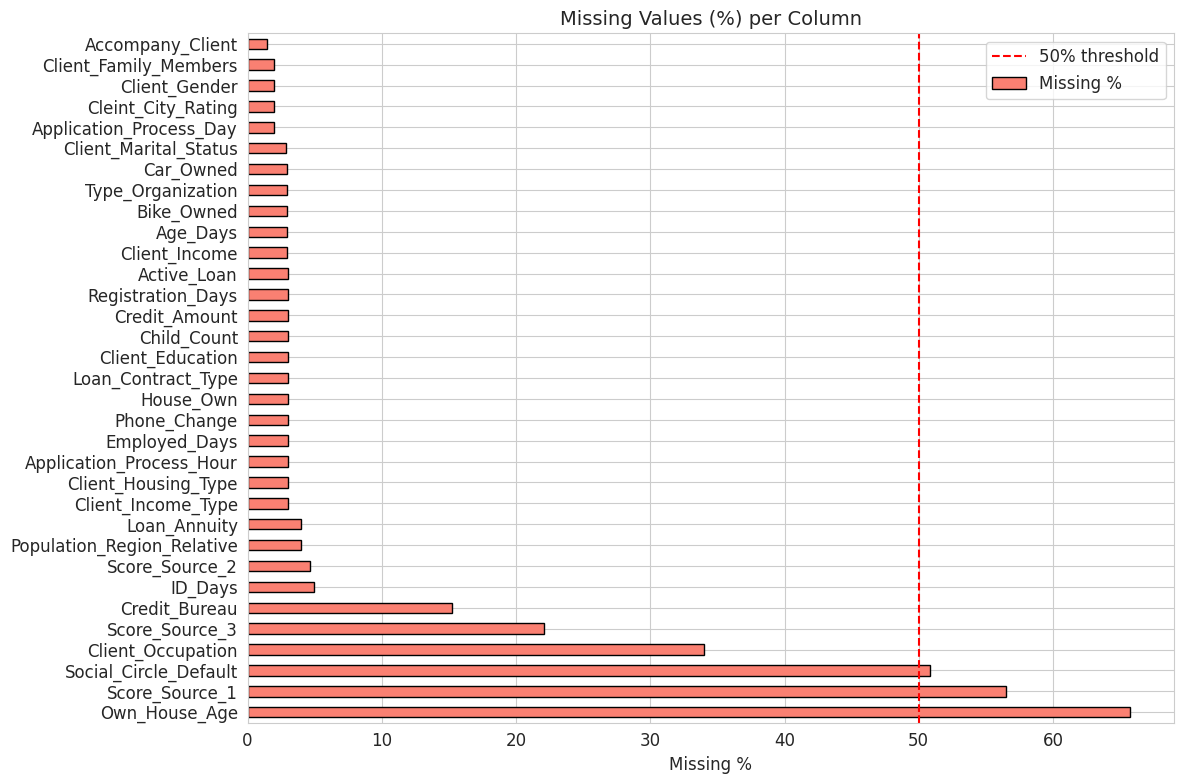

In [12]:
# Visualize missing values
plt.figure(figsize=(12, 8))
missing_df['Missing %'].plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Missing Values (%) per Column', fontsize=14)
plt.xlabel('Missing %')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Columns with more than 50% missing - we might drop these
high_missing = missing_df[missing_df['Missing %'] > 50]
print("Columns with more than 50% missing values:")
print(high_missing)

Columns with more than 50% missing values:
                       Missing Count  Missing %
Own_House_Age                  80095      65.73
Score_Source_1                 68835      56.49
Social_Circle_Default          61928      50.82


## 5. Target Variable Analysis (Default)

Let's check how balanced our target column "Default" is.

In [14]:
target_counts = df['Default'].value_counts()
target_percent = df['Default'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(f"  No Default (0): {target_counts[0]} rows ({target_percent[0]:.1f}%)")
print(f"  Default    (1): {target_counts[1]} rows ({target_percent[1]:.1f}%)")
print(f"\nClass Imbalance Ratio: {target_counts[0] / target_counts[1]:.1f}:1")

Target Distribution:
  No Default (0): 112011 rows (91.9%)
  Default    (1): 9845 rows (8.1%)

Class Imbalance Ratio: 11.4:1


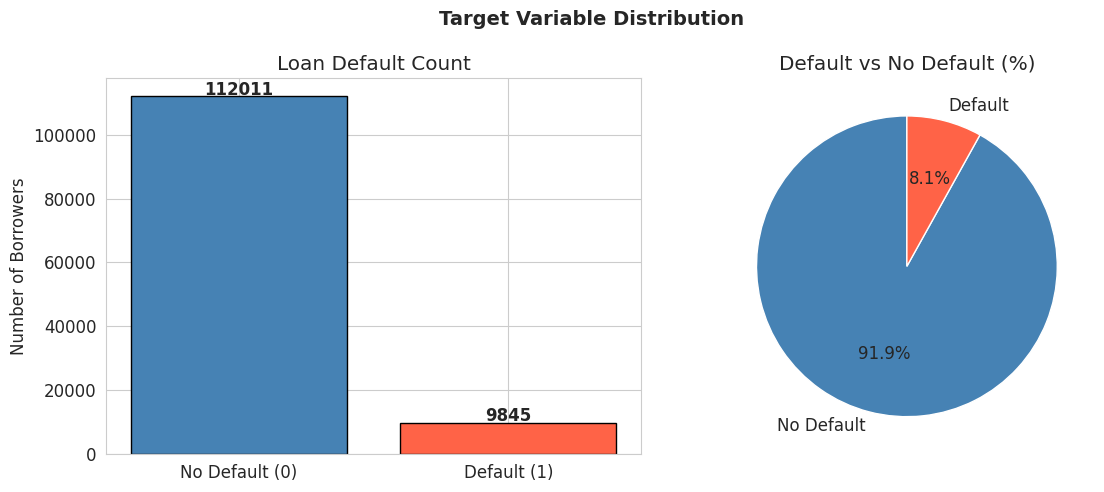


 The dataset is highly imbalanced. We'll handle this using SMOTE during model training.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Loan Default Count')
axes[0].set_ylabel('Number of Borrowers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Default', 'Default'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Default vs No Default (%)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n The dataset is highly imbalanced. We'll handle this using SMOTE during model training.")

## 6. Statistical Summary

In [17]:
# Summary statistics for numeric columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,121856.0,12160928.50,35176.94,12100001.00,12130464.75,12160928.50,12191392.25,12221856.00
Client_Income,118234.0,16865.19,11538.15,2565.00,11250.00,14400.00,20250.00,1800009.00
Car_Owned,118275.0,0.34,0.47,0.00,0.00,0.00,1.00,1.00
Bike_Owned,118232.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
Active_Loan,118221.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00
House_Own,118195.0,0.69,0.46,0.00,0.00,1.00,1.00,1.00
Child_Count,118218.0,0.42,0.73,0.00,0.00,0.00,1.00,19.00
Credit_Amount,118219.0,60046.49,40350.66,4500.00,27000.00,51750.00,80865.00,405000.00
Loan_Annuity,117030.0,2721.25,1461.47,217.35,1657.35,2499.75,3466.80,22500.00
Population_Region_Relative,116988.0,0.02,0.41,0.00,0.01,0.02,0.03,100.00


## 7. Numerical Feature Distributions

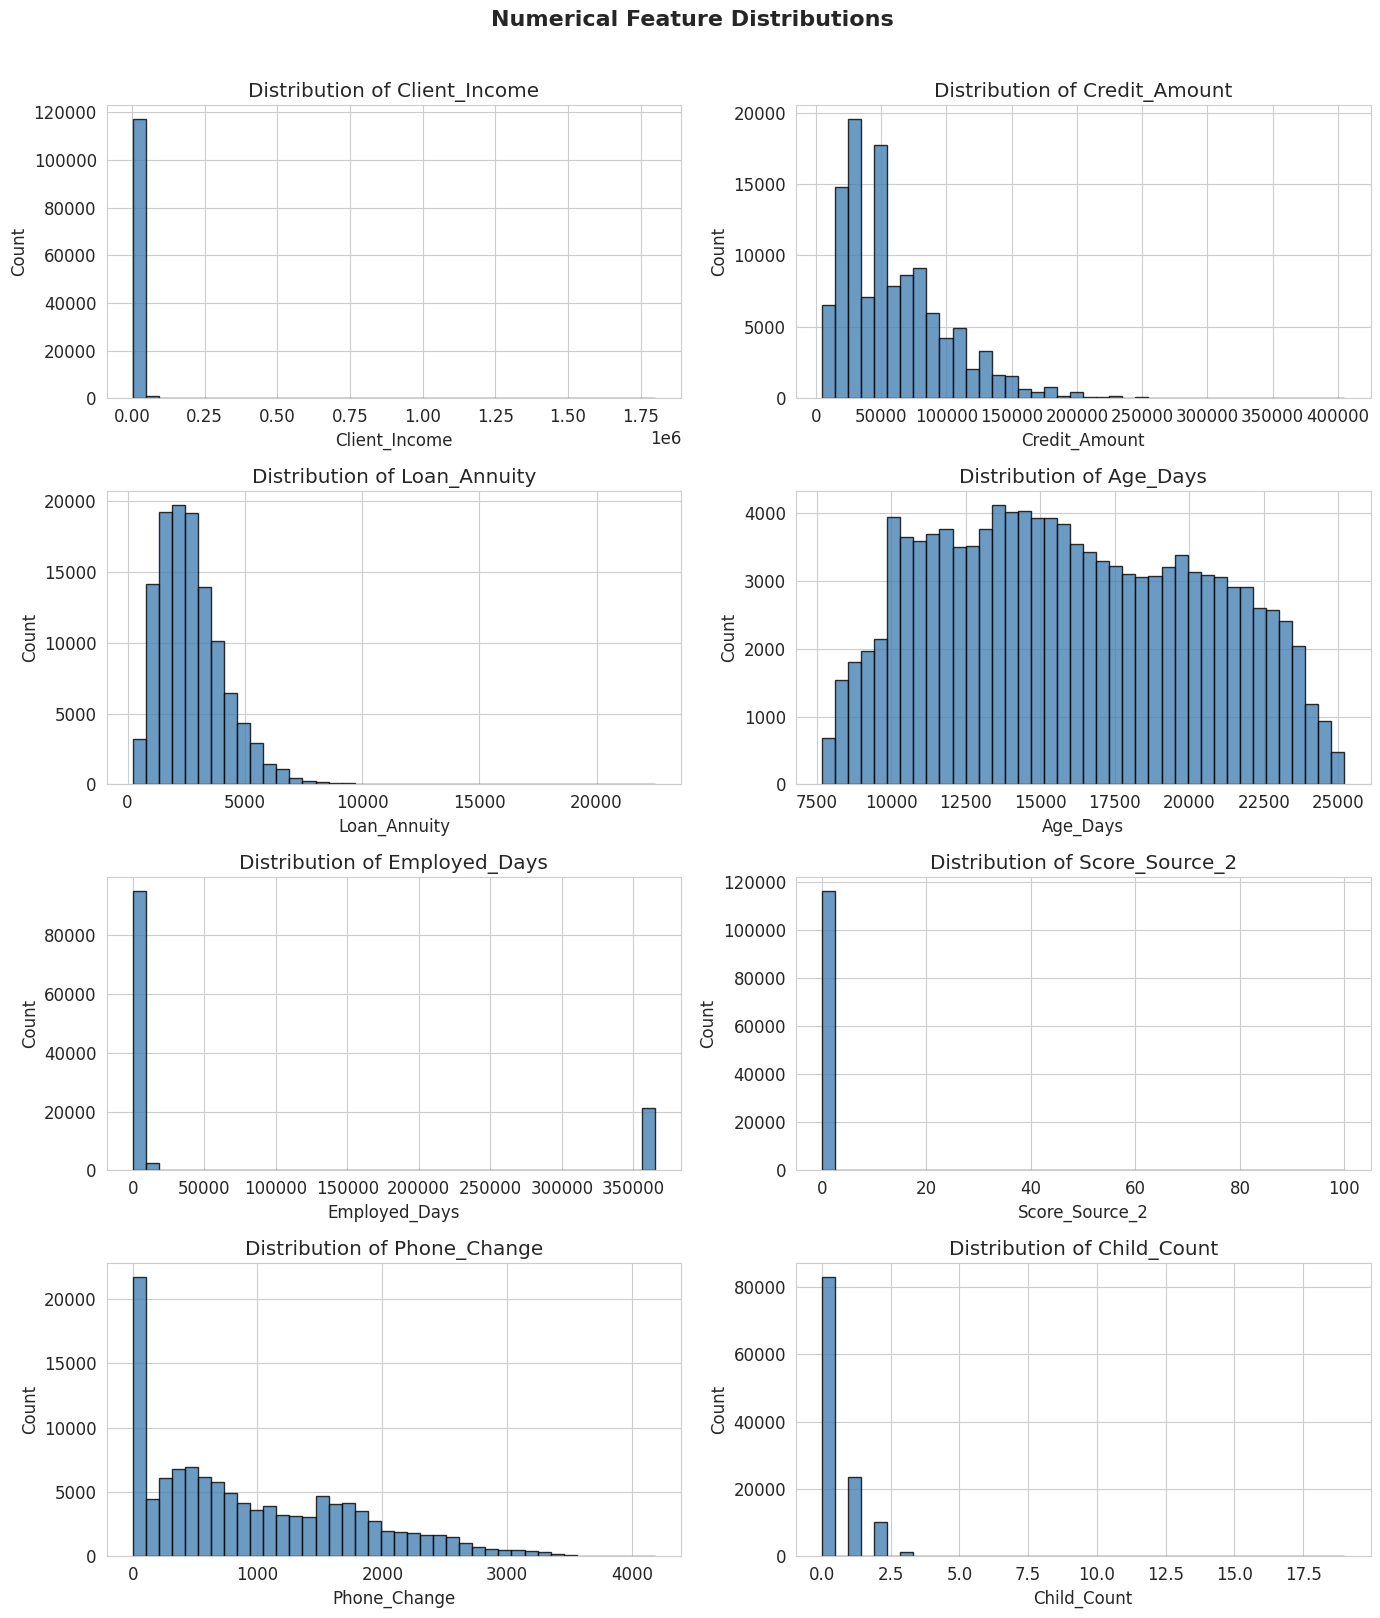

In [18]:
# Select main numeric features to plot
num_features = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days',
                'Employed_Days', 'Score_Source_2', 'Phone_Change', 'Child_Count']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Outlier Detection

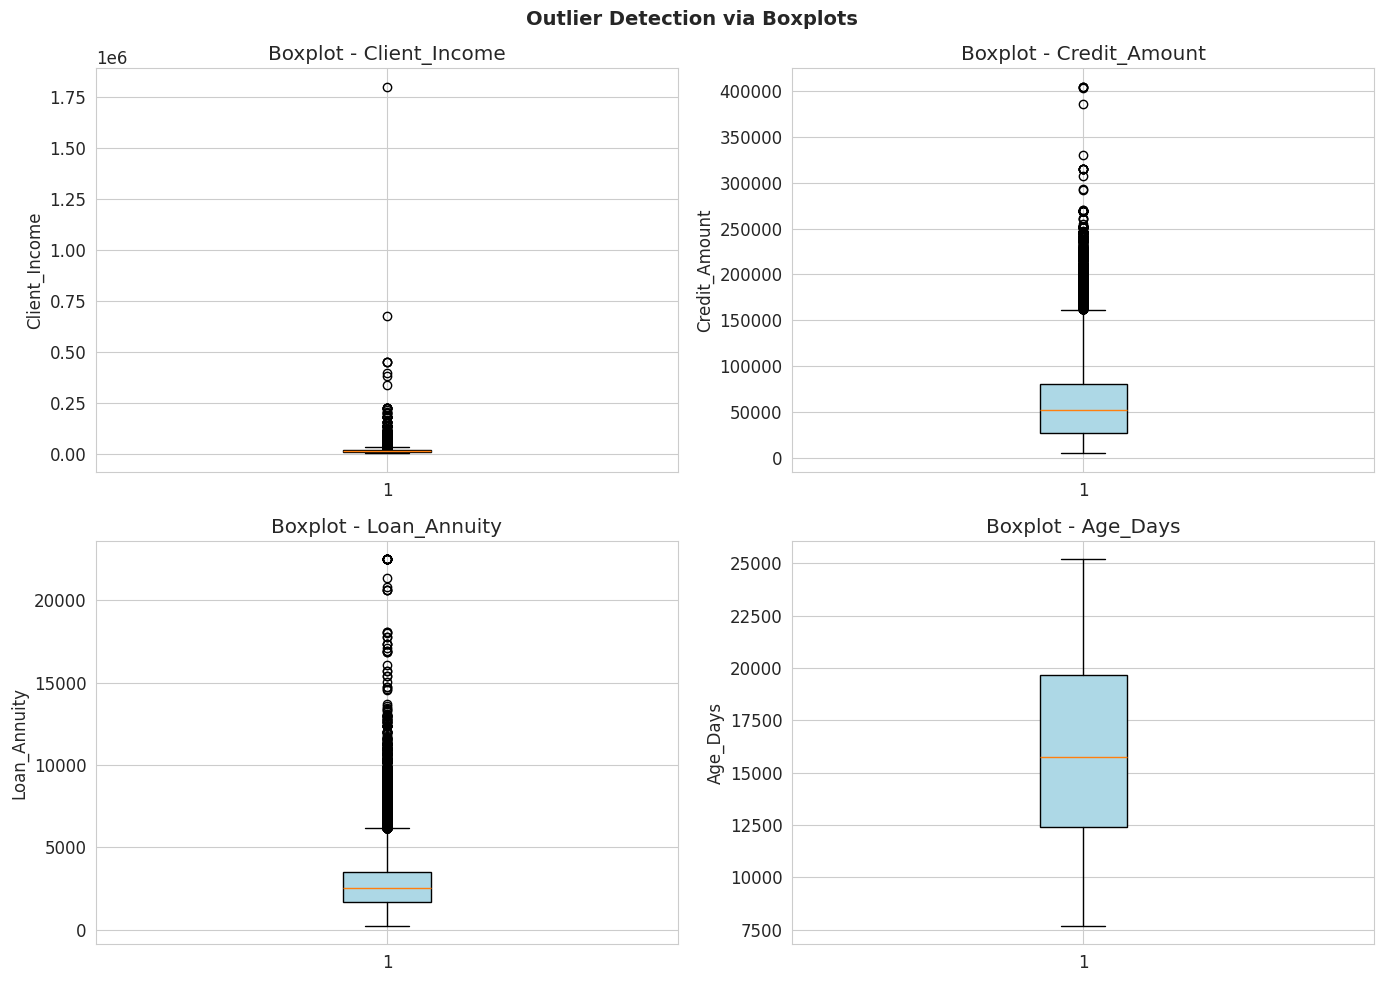

In [19]:
# Box plots to spot outliers
outlier_features = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Age_Days']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='black'))
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Check how many outliers exist using IQR method
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print("Outlier Count per Column (IQR Method):")
for col in outlier_features:
    count = count_outliers(df[col].dropna())
    print(f"  {col}: {count} outliers")

Outlier Count per Column (IQR Method):
  Client_Income: 5392 outliers
  Credit_Amount: 2567 outliers
  Loan_Annuity: 2894 outliers
  Age_Days: 0 outliers


## 9. Categorical Feature Analysis

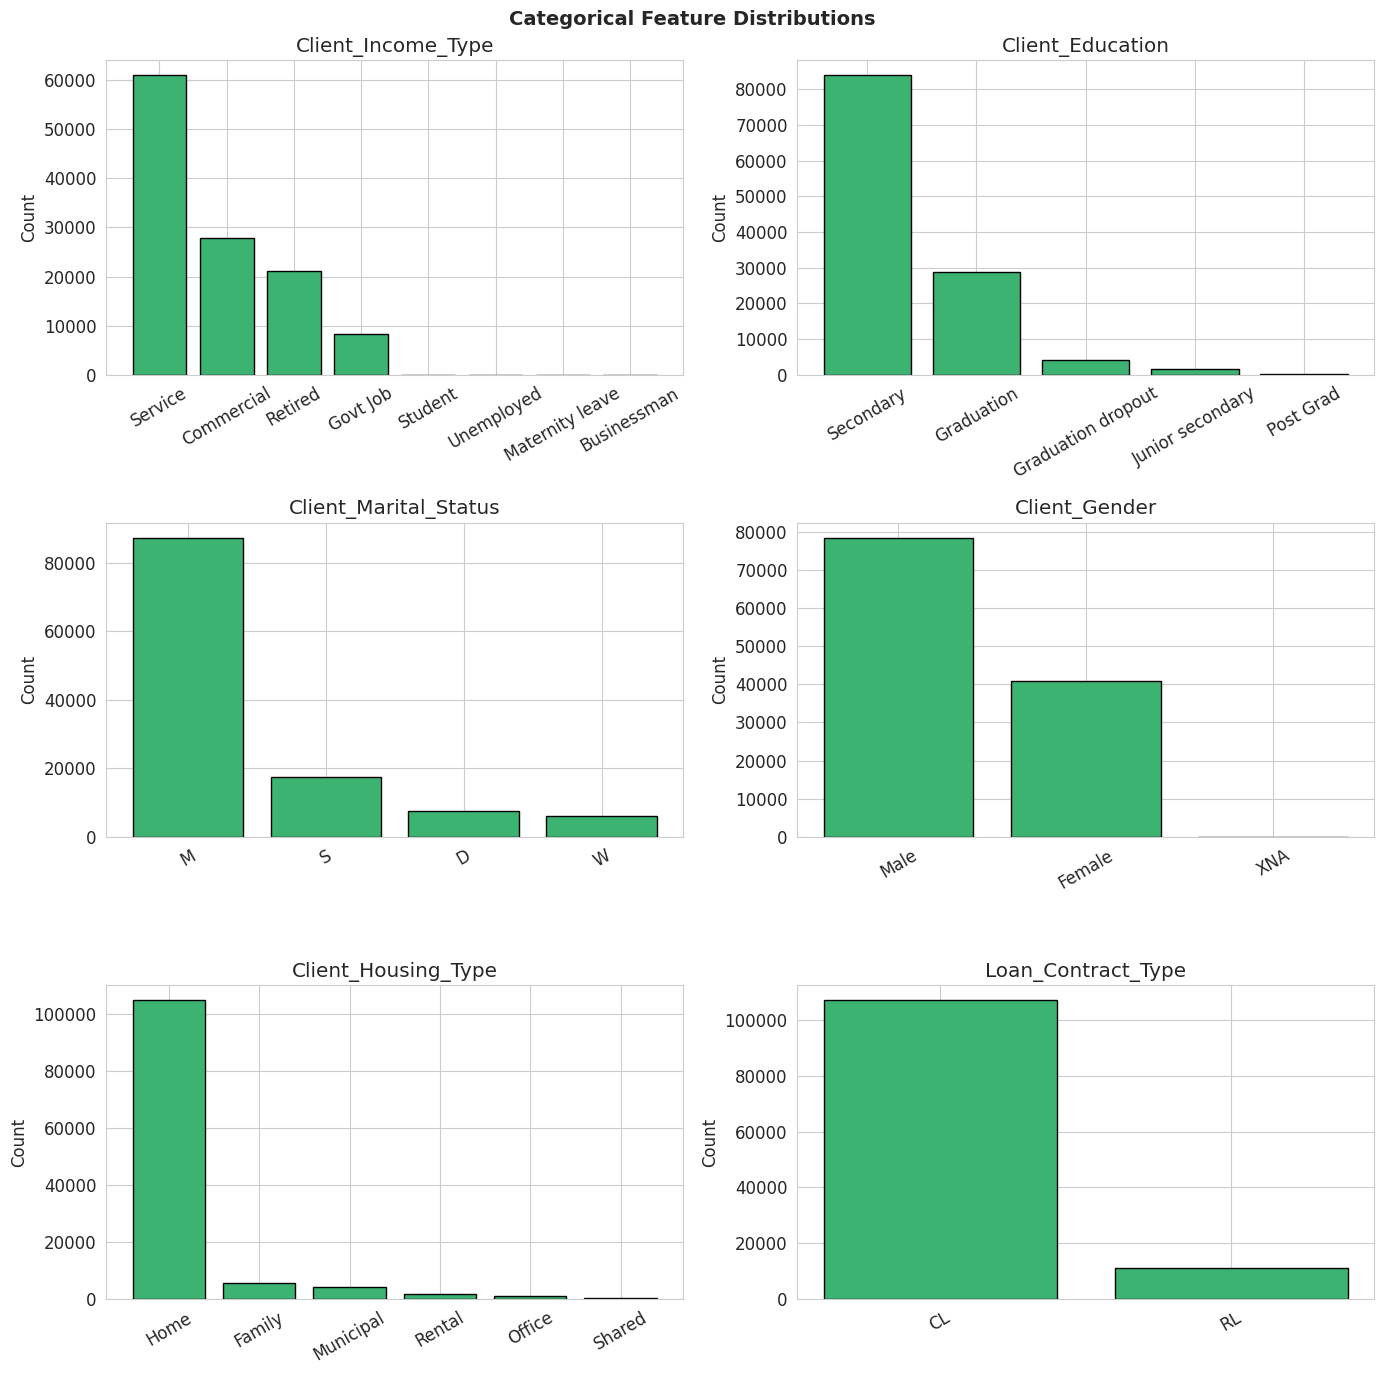

In [21]:
cat_features = [
    'Client_Income_Type', 'Client_Education',
    'Client_Marital_Status', 'Client_Gender',
    'Client_Housing_Type', 'Loan_Contract_Type'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color='mediumseagreen', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature vs Target Analysis

How does each feature relate to loan default?

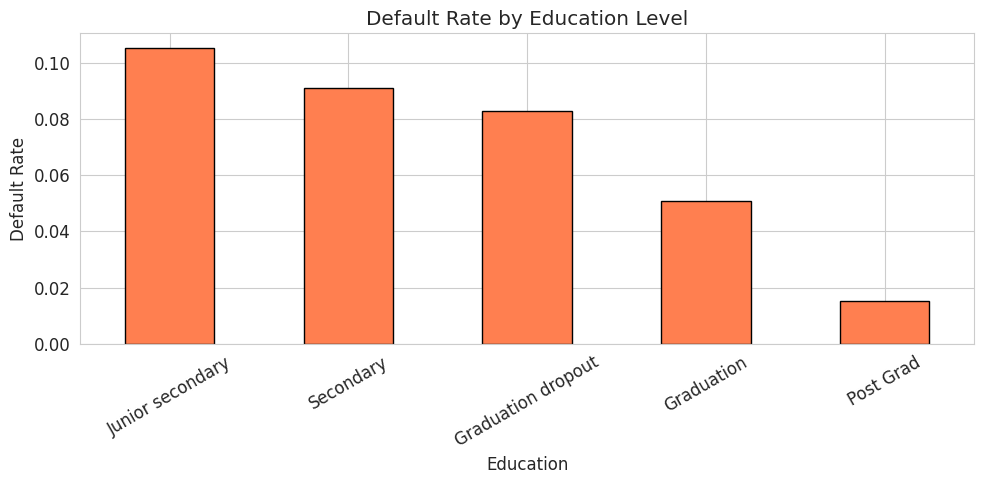

In [22]:
# Default rate by Client Education
edu_default = df.groupby('Client_Education')['Default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
edu_default.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Default Rate by Education Level')
plt.ylabel('Default Rate')
plt.xlabel('Education')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

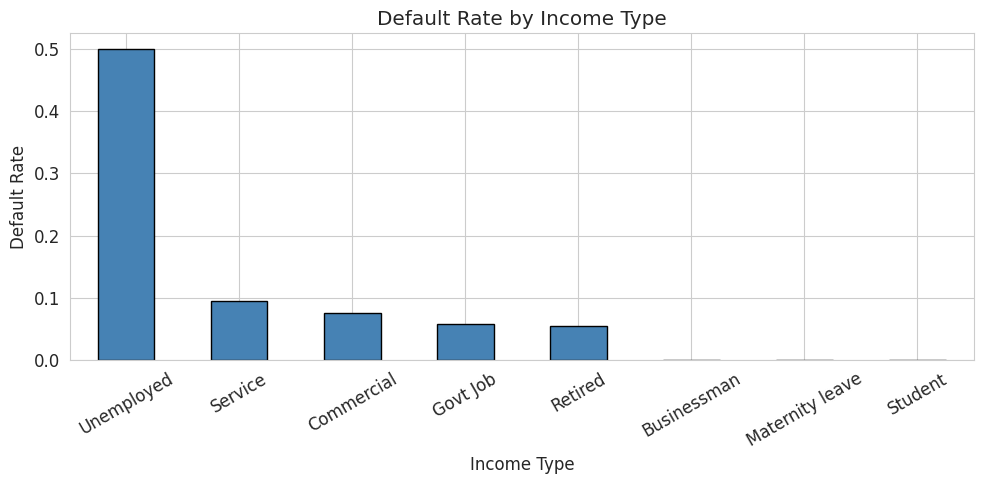

In [23]:
# Default rate by Income Type
income_default = df.groupby('Client_Income_Type')['Default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
income_default.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Default Rate by Income Type')
plt.ylabel('Default Rate')
plt.xlabel('Income Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

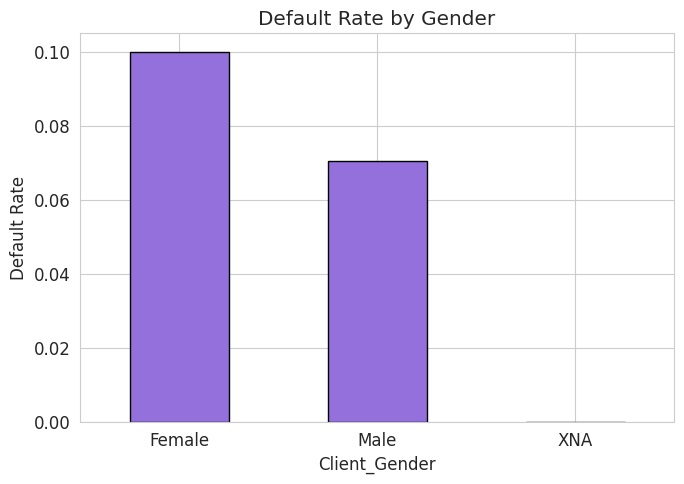

In [24]:
# Default rate by Gender
gender_default = df.groupby('Client_Gender')['Default'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
gender_default.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Default Rate by Gender')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

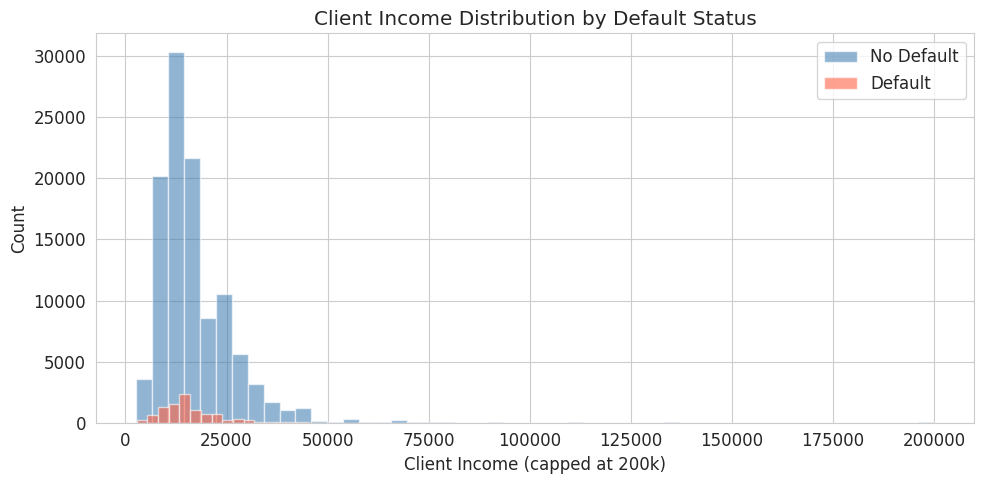

In [25]:
# Income distribution: Defaulters vs Non-Defaulters
plt.figure(figsize=(10, 5))
df[df['Default'] == 0]['Client_Income'].dropna().clip(upper=200000).hist(
    bins=50, alpha=0.6, label='No Default', color='steelblue')
df[df['Default'] == 1]['Client_Income'].dropna().clip(upper=200000).hist(
    bins=50, alpha=0.6, label='Default', color='tomato')
plt.title('Client Income Distribution by Default Status')
plt.xlabel('Client Income (capped at 200k)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

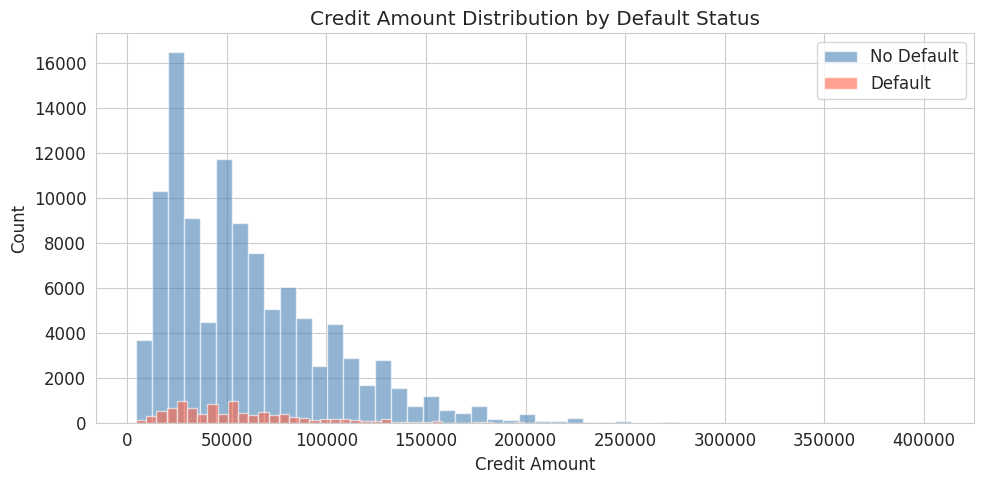

In [26]:
# Credit Amount vs Default
plt.figure(figsize=(10, 5))
df[df['Default'] == 0]['Credit_Amount'].dropna().clip(upper=1000000).hist(
    bins=50, alpha=0.6, label='No Default', color='steelblue')
df[df['Default'] == 1]['Credit_Amount'].dropna().clip(upper=1000000).hist(
    bins=50, alpha=0.6, label='Default', color='tomato')
plt.title('Credit Amount Distribution by Default Status')
plt.xlabel('Credit Amount')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap

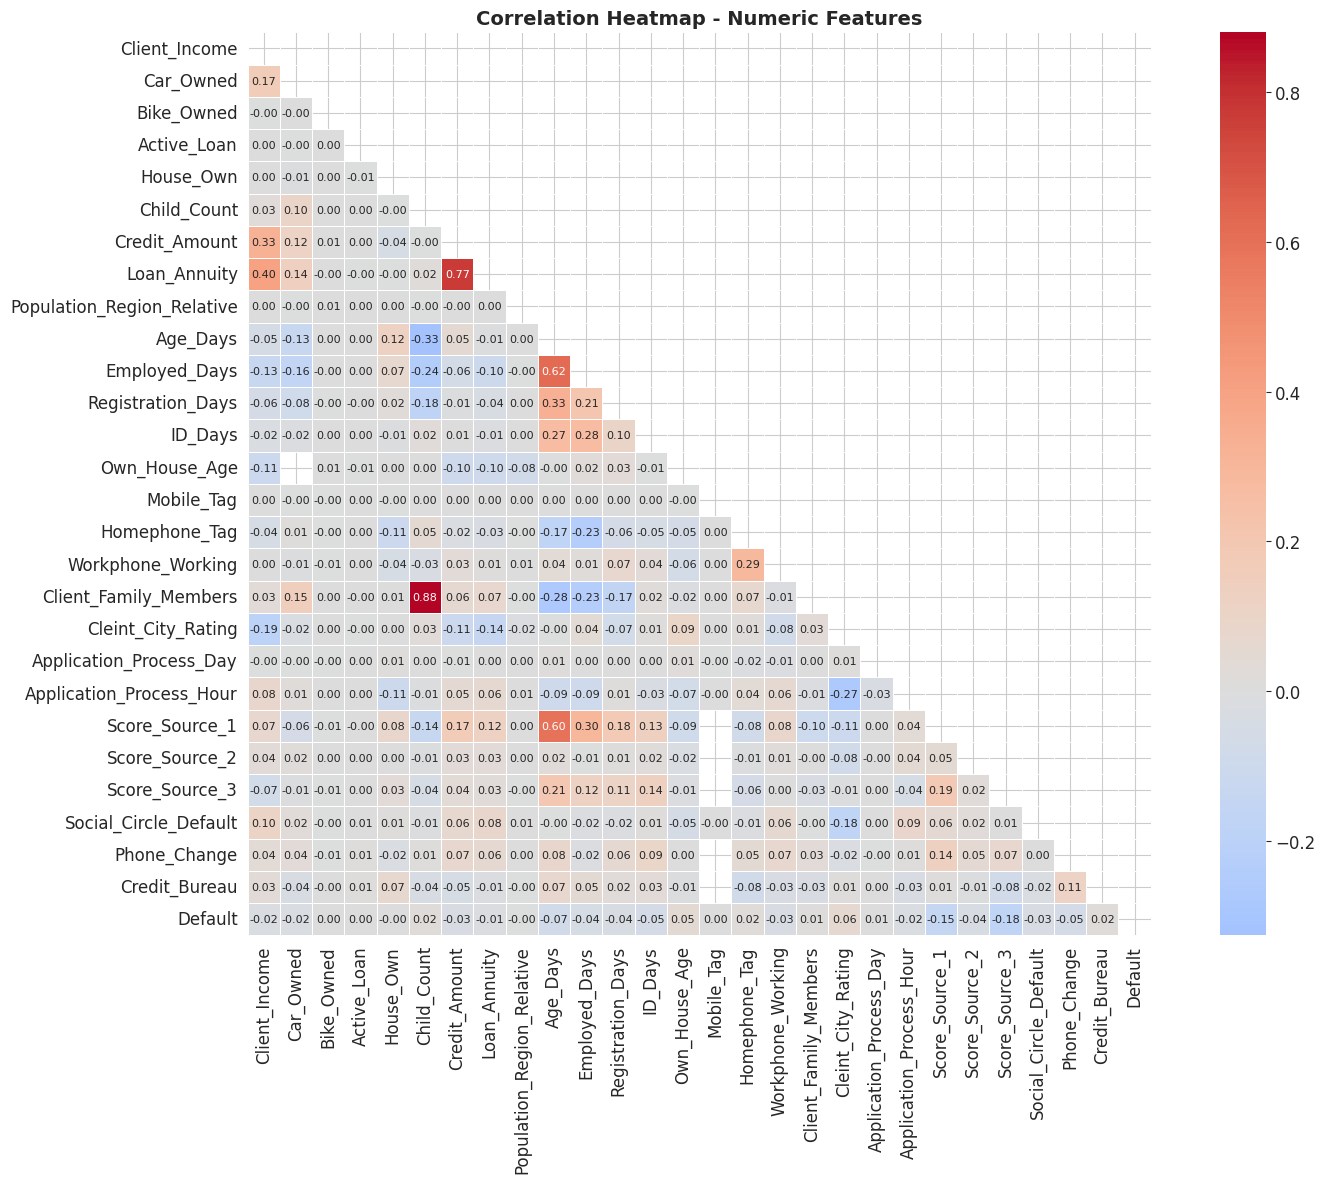

In [27]:
# Select numeric columns only for correlation
numeric_df = df.select_dtypes(include='number')

# Drop ID column as it's not useful
numeric_df = numeric_df.drop(columns=['ID'], errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

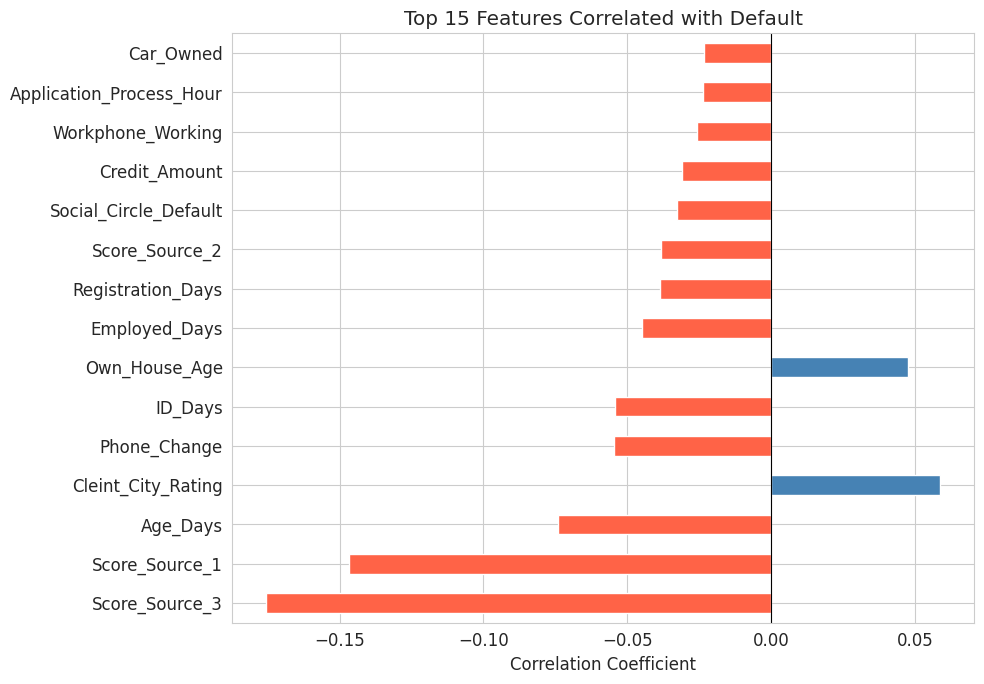


Top features correlated with Default:
Score_Source_3             -0.175513
Score_Source_1             -0.146809
Age_Days                   -0.074074
Cleint_City_Rating          0.058857
Phone_Change               -0.054591
ID_Days                    -0.054089
Own_House_Age               0.047513
Employed_Days              -0.044861
Registration_Days          -0.038524
Score_Source_2             -0.038085
Social_Circle_Default      -0.032631
Credit_Amount              -0.031049
Workphone_Working          -0.025682
Application_Process_Hour   -0.023589
Car_Owned                  -0.023221
Name: Default, dtype: float64


In [28]:
# See which features correlate most with Default
default_corr = corr_matrix['Default'].drop('Default').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
default_corr.head(15).plot(kind='barh', color=['tomato' if x < 0 else 'steelblue' for x in default_corr.head(15)])
plt.title('Top 15 Features Correlated with Default')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop features correlated with Default:")
print(default_corr.head(15))

## 12. Loan-to-Income Ratio Analysis

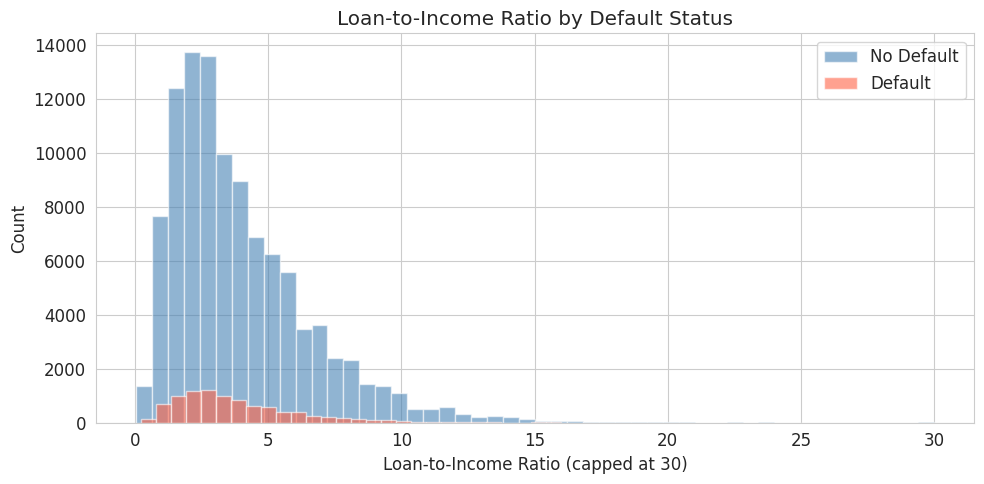

In [29]:
# Create a new feature: Loan to Income Ratio
df['Loan_to_Income'] = df['Credit_Amount'] / (df['Client_Income'] + 1)

plt.figure(figsize=(10, 5))
df[df['Default'] == 0]['Loan_to_Income'].clip(0, 30).hist(
    bins=50, alpha=0.6, label='No Default', color='steelblue')
df[df['Default'] == 1]['Loan_to_Income'].clip(0, 30).hist(
    bins=50, alpha=0.6, label='Default', color='tomato')
plt.title('Loan-to-Income Ratio by Default Status')
plt.xlabel('Loan-to-Income Ratio (capped at 30)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Age and Employment Analysis

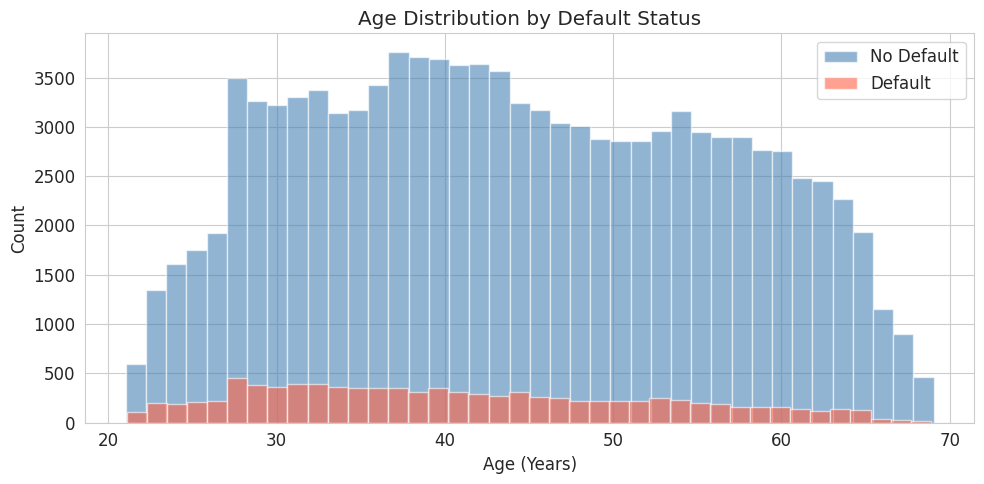

In [30]:
# Convert Age_Days to Years for readability
df['Age_Years'] = df['Age_Days'] / 365

plt.figure(figsize=(10, 5))
df[df['Default'] == 0]['Age_Years'].dropna().hist(
    bins=40, alpha=0.6, label='No Default', color='steelblue')
df[df['Default'] == 1]['Age_Years'].dropna().hist(
    bins=40, alpha=0.6, label='Default', color='tomato')
plt.title('Age Distribution by Default Status')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

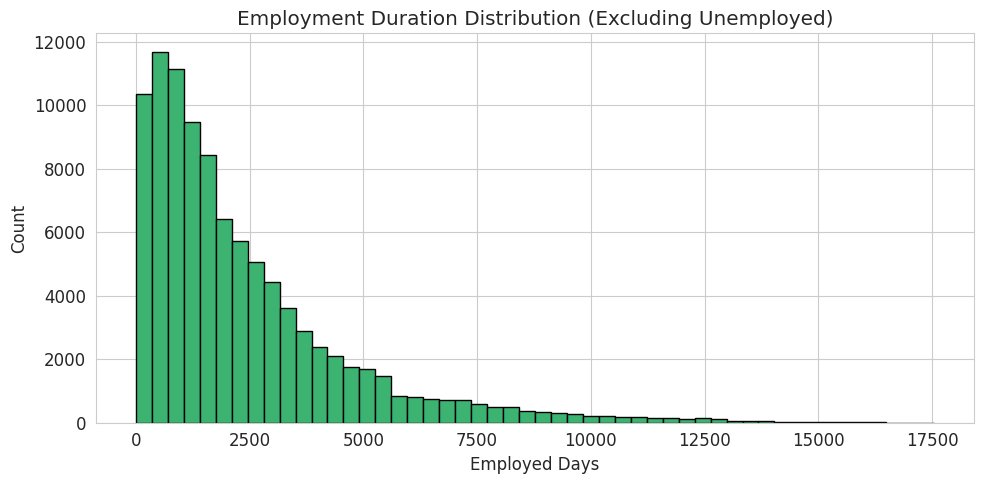


Rows where Employed_Days = 365243 (likely unemployed): 21098


In [31]:
# Employed Days - remove outlier value 365243 (means unemployed)
employed_clean = df[df['Employed_Days'] != 365243]['Employed_Days']

plt.figure(figsize=(10, 5))
employed_clean.hist(bins=50, color='mediumseagreen', edgecolor='black')
plt.title('Employment Duration Distribution (Excluding Unemployed)')
plt.xlabel('Employed Days')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"\nRows where Employed_Days = 365243 (likely unemployed): {(df['Employed_Days'] == 365243).sum()}")

## 14. Application Time Analysis

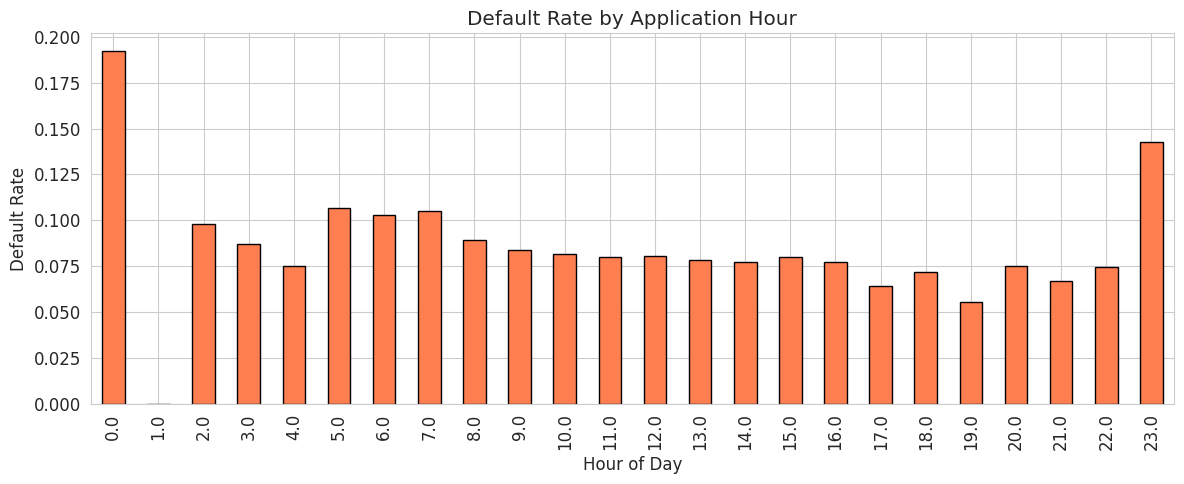

In [32]:
# Default rate by application hour
hour_default = df.groupby('Application_Process_Hour')['Default'].mean()

plt.figure(figsize=(12, 5))
hour_default.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Default Rate by Application Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

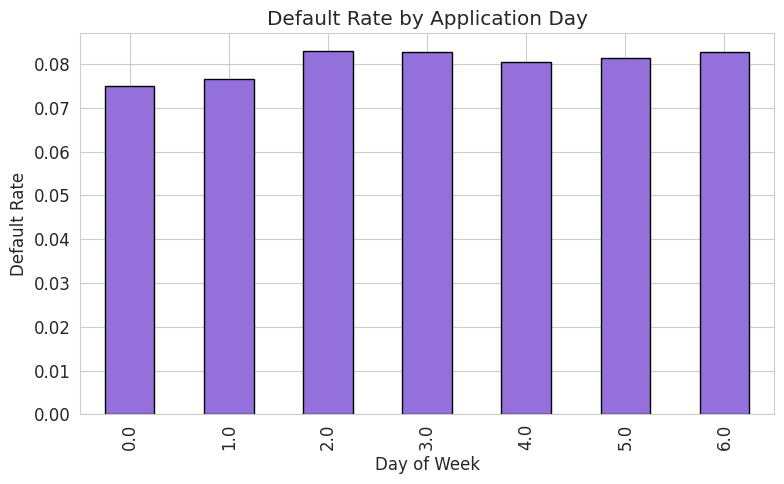

In [33]:
# Default rate by day of week
day_default = df.groupby('Application_Process_Day')['Default'].mean()
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

plt.figure(figsize=(8, 5))
day_default.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Default Rate by Application Day')
plt.xlabel('Day of Week')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

## 15. Feature Engineering Preview

These are the new features we'll create during preprocessing to improve the model.

In [34]:
# Preview of feature engineering steps (will be done in model.py)

df['Age_Years']        = df['Age_Days'] / 365
df['Loan_to_Income']   = df['Credit_Amount'] / (df['Client_Income'] + 1)
df['Annuity_to_Income']= df['Loan_Annuity'] / (df['Client_Income'] + 1)
df['Is_Unemployed']    = (df['Employed_Days'] == 365243).astype(int)

print("New features created:")
print(df[['Age_Years', 'Loan_to_Income', 'Annuity_to_Income', 'Is_Unemployed']].describe().round(3))

New features created:
        Age_Years  Loan_to_Income  Annuity_to_Income  Is_Unemployed
count  118239.000      114708.000         113566.000     121856.000
mean       43.911           3.967              0.182          0.173
std        11.963           2.700              0.095          0.378
min        21.030           0.037              0.004          0.000
25%        33.967           2.026              0.115          0.000
50%        43.107           3.281              0.164          0.000
75%        53.866           5.172              0.230          0.000
max        69.044          49.216              1.570          1.000


## Summary and Key Findings


Dataset Overview:
  - Total records      : 121,856
  - Total features     : 44
  - Default rate       : 8.1%

Data Quality Issues:
  - Columns with missing values : 36
  - Columns with >50% missing   : 3
  - Columns needing type fix     : 9 (stored as text)

Class Imbalance:
  - No Default (0) : 112,011 (91.9%)
  - Default    (1) : 9,845 (8.1%)
  - Will handle using SMOTE

Key Observations:
  - Employed_Days = 365243 means unemployed (special flag)
  - Score_Source_1 and Social_Circle_Default have 50%+ missing
  - Loan-to-income ratio differs between defaulters and non-defaulters
  - Younger borrowers tend to default slightly more
  - Some income types have much higher default rates